# 📊 Evaluación Sumativa Final - Inferencia Estadística Paramétrica
## Dataset Regional: Remuneraciones e Ingresos Adicionales del Municipio de Loja
**Estudiante:** Gabriel Alejandro Suarez Poma  
**Carrera:** Computación  

### Objetivos:
1. Validar suposiciones críticas de un parámetro regional mediante una Prueba de Hipótesis Unimuestral ($T$ de Student).
2. Comparar múltiples grupos organizados por Régimen Laboral mediante ANOVA de 1 factor y la prueba Post-Hoc de Tukey.



In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración visual profesional para el reporte
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 14, "axes.labelsize": 12})

print("✅ Librerías científicas cargadas con éxito.")

✅ Librerías científicas cargadas con éxito.


## 📐 Sección 1: Prueba de Hipótesis Unimuestral ($T$ de Student)
Evaluaremos si la media poblacional real del salario base difiere de un valor de referencia asumido históricamente de $\mu_0 = 850$ USD.

Formalismo Matemático:
$$H_0: \mu = 850$$
$$H_1: \mu \neq 850$$

Utilizaremos el estadístico $T$ debido a que la varianza poblacional es desconocida:
$$T = \frac{\bar{X} - \mu_0}{S / \sqrt{n}}$$

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración visual profesional para el reporte
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 14, "axes.labelsize": 12})

print("✅ Librerías científicas cargadas con éxito.")

# Carga y limpieza de datos regionales
df = pd.read_excel('3._remuneraciones_ingresos_adicionales (2).xlsx')

# Formatear la variable objetivo a numérico
df['Remuneración mensual unificada'] = pd.to_numeric(df['Remuneración mensual unificada'], errors='coerce')
df = df.dropna(subset=['Remuneración mensual unificada'])

mu_0 = 850.0
alpha = 0.05
datos_salarios = df['Remuneración mensual unificada'].values

# Ejecución del test paramétrico
stat_t, p_value_t = stats.ttest_1samp(datos_salarios, popmean=mu_0)

print("--- RESULTADOS PRUEBA T UNIMUESTRAL ---")
print(f"Media Muestral Calculada: {np.mean(datos_salarios):.2f} USD")
print(f"Grados de Libertad (n-1): {len(datos_salarios) - 1}")
print(f"Estadístico T: {stat_t:.4f}")
print(f"Valor-p: {p_value_t:.4e}")

if p_value_t < alpha:
    print(f"\nConclusión: Como valor-p ({p_value_t:.4e}) < alpha ({alpha}), se RECHAZA H0.")
else:
    print(f"\nConclusión: Como valor-p ({p_value_t:.4e}) >= alpha ({alpha}), NO se rechaza H0.")

✅ Librerías científicas cargadas con éxito.
--- RESULTADOS PRUEBA T UNIMUESTRAL ---
Media Muestral Calculada: 713.81 USD
Grados de Libertad (n-1): 2882
Estadístico T: -27.5848
Valor-p: 7.6141e-149

Conclusión: Como valor-p (7.6141e-149) < alpha (0.05), se RECHAZA H0.


## 🌎 Sección 2: Análisis Multigrupo (ANOVA de 1 Factor y Tukey)
Dividiremos el conjunto de datos según la ley laboral que los rige para verificar si existen asimetrías significativas en la asignación de sus ingresos adicionales.

Formulación de Hipótesis:
$$H_0: \mu_{\text{LOSEP}} = \mu_{\text{Código de Trabajo}}$$
$$H_1: \text{Al menos una de las medias es diferente.}$$

--- TABLA ANOVA ---
                                                sum_sq      df           F  \
C(Q("Régimen laboral al que pertenece"))  1.403286e+06     1.0  284.738982   
Residual                                  1.345925e+07  2731.0         NaN   

                                                PR(>F)  
C(Q("Régimen laboral al que pertenece"))  7.582600e-61  
Residual                                           NaN  

Efecto significativo detectado. Desplegando prueba Post-Hoc:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
      group1      group2 meandiff p-adj  lower   upper   reject
---------------------------------------------------------------
CODIGO DE TRABAJO  LOSEP -45.3609   0.0 -50.632 -40.0898   True
---------------------------------------------------------------


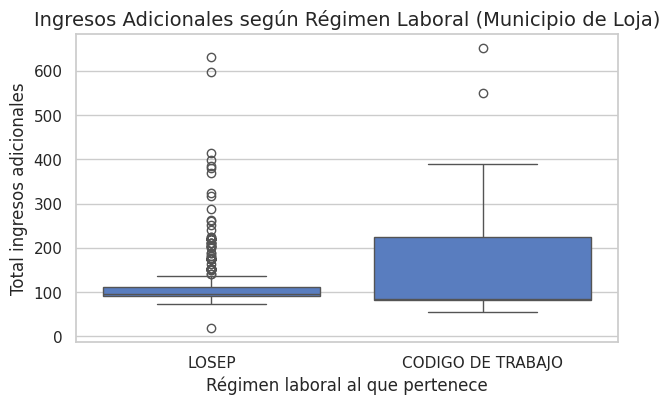

In [17]:
# Preparación de variables de contraste
df.columns = df.columns.str.strip()
df['Total ingresos adicionales'] = pd.to_numeric(df['Total ingresos adicionales'], errors='coerce')
df['Régimen laboral al que pertenece'] = df['Régimen laboral al que pertenece'].astype(str).str.strip()
df_clean = df.dropna(subset=['Total ingresos adicionales', 'Régimen laboral al que pertenece'])

# Filtrado de subgrupos representativos
regimenes = ['LOSEP', 'CODIGO DE TRABAJO']
df_filtered = df_clean[df_clean['Régimen laboral al que pertenece'].isin(regimenes)]

# Ajuste del modelo matemático OLS para ANOVA
modelo = ols('Q("Total ingresos adicionales") ~ C(Q("Régimen laboral al que pertenece"))', data=df_filtered).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print("--- TABLA ANOVA ---")
print(tabla_anova)

# Ejecución Condicional de la prueba Post-Hoc de Tukey
p_anova = tabla_anova['PR(>F)'].iloc[0]
if p_anova < 0.05:
    print("\nEfecto significativo detectado. Desplegando prueba Post-Hoc:")
    tukey = pairwise_tukeyhsd(endog=df_filtered['Total ingresos adicionales'],
                              groups=df_filtered['Régimen laboral al que pertenece'],
                              alpha=0.05)
    print(tukey)

# Boxplot descriptivo para la defensa en video
plt.figure(figsize=(7, 4))
sns.boxplot(x='Régimen laboral al que pertenece', y='Total ingresos adicionales', data=df_filtered)
plt.title('Ingresos Adicionales según Régimen Laboral (Municipio de Loja)')
plt.show()